# 6.2 DeepFM 排序

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何在不手工枚举所有组合的情况下，同时学习一阶、二阶和高阶稀疏特征交互？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand-Pure（smoke 教学适配器）；full 档使用 Criteo_x1 官方 7:2:1 切分**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。

**主要资料：** [Guo et al., 2017, DeepFM](https://arxiv.org/abs/1703.04247)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "criteo-x1"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'criteo-x1', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': True, 'cuda_device': 'NVIDIA RTX 6000 Ada Generation'}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何在不手工枚举所有组合的情况下，同时学习一阶、二阶和高阶稀疏特征交互？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

DeepFM（IJCAI 2017，华为诺亚方舟实验室）针对 CTR 预估中低阶与高阶交互难以兼得的问题：FNN 要先拿 FM 预训练 embedding 才能用，PNN 只学高阶，Wide & Deep 的 wide 侧仍要人工叉乘特征。论文让 FM 与 DNN 共享同一份输入与 embedding，端到端联合训练，离线在 Criteo 与公司数据上同时报告最优 AUC 与 LogLoss。它没有做的：没有自己的在线 A/B（只引用 Wide & Deep 的线上经验），不建模行为序列，不处理曝光偏差与概率校准；Criteo 用随机 9:1 切分，比时间切分宽松。

**来源：** [Guo et al., 2017, DeepFM](https://arxiv.org/abs/1703.04247)

### 原文实验设计与关键结论

原文 Table 2：Criteo（约 4,500 万条点击记录，13 连续 + 26 离散特征，随机 9:1 切分）上 DeepFM AUC 0.8007、LogLoss 0.45083，优于 FM（0.7892/0.46077）与最佳 PNN 变体（0.7987/0.45214）；Company*（约 10 亿条记录，7 天训练 + 次日测试）上 AUC 0.8715、LogLoss 0.02618。相对 LR，AUC 提升 0.86%/4.18%（Company*/Criteo），LogLoss 降低 1.15%/5.60%；相对用独立 embedding 的 LR&DNN/FM&DNN 仍高 0.48%/0.33%。深度模型统一 400-400-400、dropout 0.5，FM 隐向量维度 10。教程使用 KuaiRand 完整曝光重新测量并保留 LR 对照，两套数值不能相减。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** Criteo Display Ads  
**资源 ID：** `criteo-x1-full`  
**切分：** 7:2:1 fixed split from Criteo_x1  
**指标：** AUC, LogLoss  
**与论文比较边界：** 按配置中的 paper_targets 逐指标对照

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 1 · DeepFM wide and deep architecture](/static/paper-figures/deepfm.webp)

> **论文原图节选** · Figure 1 · DeepFM wide and deep architecture · PDF p.1。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **共享稠密 Embedding**：FM 与 DNN 从同一组稀疏特征 embedding 出发，端到端联合训练，不需要人工分两路特征。
- **FM 二阶分支**：用隐向量内积自动学任意两个特征的二阶交互，O(nd) 展开避免枚举所有特征对。
- **DNN 高阶分支**：把 embedding 拼接送入多层全连接，学习三阶及以上的组合模式；三路 logit（一阶 + FM + DNN）相加后 Sigmoid 出 CTR。

### 结构：Linear、FM 与 DNN 三路相加

一条样本是 m 个 field 的稀疏向量 $x$。field 就是特征分组：性别是一个 field，视频类别是一个 field，小时是一个 field。每个特征 $i$ 同时拥有一阶权重 $w_i$（标量）和隐向量 $V_i\in\mathbb R^k$。

最终 logit 分三路：一阶线性项记住单特征分量，FM 二阶项显式算特征对交互，DNN 从同一组 embedding 学高阶组合：

$$z=w_0+\sum_iw_ix_i+\sum_{i<j}\langle V_i,V_j\rangle x_ix_j+\mathrm{MLP}([V_ix_i]_i),\quad p=\sigma(z).$$

| 符号 | 含义 |
|---|---|
| $x_i$ | 特征 $i$ 的取值（one-hot 中为 0/1） |
| $w_i$ | 特征 $i$ 的一阶权重 |
| $V_i$ | 特征 $i$ 的 $k$ 维隐向量 |
| $\langle V_i,V_j\rangle$ | 内积 $\sum_f V_{i,f}V_{j,f}$，即二阶交互强度 |
| $\sigma$ | Sigmoid，把 logit 压成 0～1 的点击概率 |

### 为什么 FM 不用真的枚举特征对

直接算二阶项要枚举所有特征对：$n$ 个非零特征有 $n(n-1)/2$ 对，每对一次 $k$ 维内积，共 $O(n^2k)$。把内积按维度展开并交换求和顺序，可得恒等式

$$\sum_{i<j}\langle V_i,V_j\rangle x_ix_j=\frac12\sum_{f=1}^{k}\left[\left(\sum_i V_{i,f}x_i\right)^2-\sum_i (V_{i,f}x_i)^2\right],$$

右边每个维度 $f$ 只做 $n$ 次乘加，总共 $O(nk)$（实现按非零特征计，常写作 $O(nd)$，$d$ 即隐向量维度 $k$）。手算验证：取 $k=2$、两个特征 $V_1=(1,2)$、$V_2=(3,4)$、$x_1=x_2=1$。左边 $\langle V_1,V_2\rangle=1\times3+2\times4=11$；右边 $f=1$ 时 $(1+3)^2-(1^2+3^2)=16-10=6$，$f=2$ 时 $(2+4)^2-(2^2+4^2)=36-20=16$，$\tfrac12(6+16)=11$，两边相等。直觉：$(\sum_i a_i)^2$ 展开后包含所有两两乘积 $2a_ia_j$ 和平方项 $a_i^2$，减掉平方项再除以 2 正好留下 $i<j$ 的配对。

### 共享 embedding 与损失

共享 embedding 指同一组 $V_i$ 同时喂给 FM 分支和 DNN 分支：反向传播时，低阶交互和高阶组合的梯度落在同一组表示上，而不是各练一套互不相干的特征——论文表 2 里它因此优于使用独立 embedding 的 LR&DNN 与 FM&DNN。输出 $p=\sigma(z)$ 后用二元交叉熵 $L=-y\log p-(1-y)\log(1-p)$：$y=1$ 时只留 $-\log p$，预测越接近 1 损失越小。例：$y=1$、$p=0.9$ 时 $L\approx0.105$；$p=0.1$ 时 $L\approx2.303$。

### 公式到代码

`run_deepfm` 将 KuaiRand 的 user、video、场景和时段编码为 field，Torch-RecHub DeepFM 内部实现三路 logit，并在真实点击标签上优化 BCE。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [样本、特征与点击标签](/notebooks/3_2_data_ml_basics#observation-label)
- [向量点积](/notebooks/3_3_linear_algebra#elementwise-dot)
- [函数复合与激活](/notebooks/3_4_calculus#functions)
- [二元交叉熵](/notebooks/3_6_information_theory#cross-entropy-kl)

### 本论文新增数学（本节详细推导）

FM 二阶项从枚举特征对化简到 O(nd)，以及 FM 与 DNN 共享同一组 embedding。

FM 二阶项是 $\sum_{i<j}\langle v_i,v_j\rangle x_ix_j$：每对非零特征贡献一次隐向量内积；Deep 分支把同一组 embedding 展平送入 MLP；最终 logit 为 linear + FM + DNN 三路相加，再经 Sigmoid 得点击概率。下面的代码用三个二维 embedding（user、item、hour）手算：user·item $=1\times0.8+0\times0.2=0.8$，user·hour $=0.2$，item·hour $=0.8\times0.2+0.2\times0.9=0.34$，三项相加约 $1.34$，就是这条样本的全部二阶交互分。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

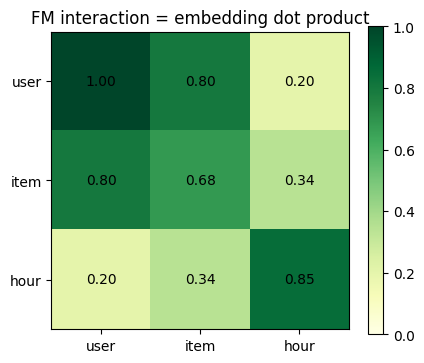

sum of three pair interactions = 1.34


In [2]:
import numpy as np, matplotlib.pyplot as plt
embedding=np.array([[1.,0.],[.8,.2],[.2,.9]]); pair=embedding@embedding.T
fig,ax=plt.subplots(figsize=(4.8,4)); image=ax.imshow(pair,cmap='YlGn',vmin=0,vmax=1)
ax.set_xticks(range(3),['user','item','hour']); ax.set_yticks(range(3),['user','item','hour'])
for i in range(3):
    for j in range(3): ax.text(j,i,f'{pair[i,j]:.2f}',ha='center',va='center')
ax.set_title('FM interaction = embedding dot product'); plt.colorbar(image,ax=ax); plt.show()
print('sum of three pair interactions =',round(pair[0,1]+pair[0,2]+pair[1,2],3))

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** Criteo Display Ads  
**资源 ID：** `criteo-x1-full`  
**切分：** 7:2:1 fixed split from Criteo_x1  
**指标：** AUC, LogLoss  
**与论文比较边界：** 按配置中的 paper_targets 逐指标对照

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实短视频曝光教学子集：user、video、场景 tab、hour、视频时长桶为特征，标签直接读取 `is_click`，按日志顺序切分。它不是 full 协议指定的 Criteo。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.ranking.DeepFM。full profile 在 TorchEasyRec 配置 sparse feature、embedding group、MLP、分布式 embedding 与模型导出。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.6_2_deepfm.train")
run_deepfm = chapter_train.run_deepfm

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_deepfm))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_deepfm(epochs: int = 28, *, progress: ProgressCallback | None = None) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    seed_everything()
    device = training_device()
    if full_profile():
        return _run_criteo_deepfm(epochs, progress=progress)
    emit_progress(progress, stage="data_prepare", current=0, total=1, message="加载 KuaiRand 排序数据")
    interactions, _, provenance = _real_kuairand(); fields, labels, frame = _ranking_fields(interactions); split = int(len(labels) * .8)
    features = [
        SparseFeature("user_id", int(max(fields["user_id"])) + 1, 12),
        SparseFeature("item_id", int(max(fields["item_id"])) + 1, 12),
        SparseFeature("tab", int(max(fields["tab"])) + 1, 12),
        SparseFeature("hour", 25, 12),
        SparseFeature("duration_bucket", int(max(fields["duration_bucket"])) + 1, 12),
    ]
    # 2) 按论文结构实例化模型；这里是理解层尺寸和特征契约的入口。
    model = DeepFM(features, features, {"dims": [48, 24], "activation": "relu", "dropout": 

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_deepfm(progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载 KuaiRand 排序数据


[data_prepare] 1/1 rows=7000


[train] 0/56 starting


[train] 3/56 epoch 2/28 batch_loss=0.504397


[train] 6/56 epoch 3/28 batch_loss=0.446649


...

[baseline] 0/1 训练独立 LR 基线


[baseline] 1/1


[evaluate] 0/1 计算 AUC 与 LogLoss


[evaluate] 1/1 auc=0.678114 logloss=0.906232


{'framework': 'torch_rechub.models.ranking.DeepFM', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'rows': 7000, 'train_rows': 5600, 'label': 'observed KuaiRand is_click'}, 'device': None, 'validation_mode': None}
inference contract: 读取请求和候选特征 → 查 embedding → 

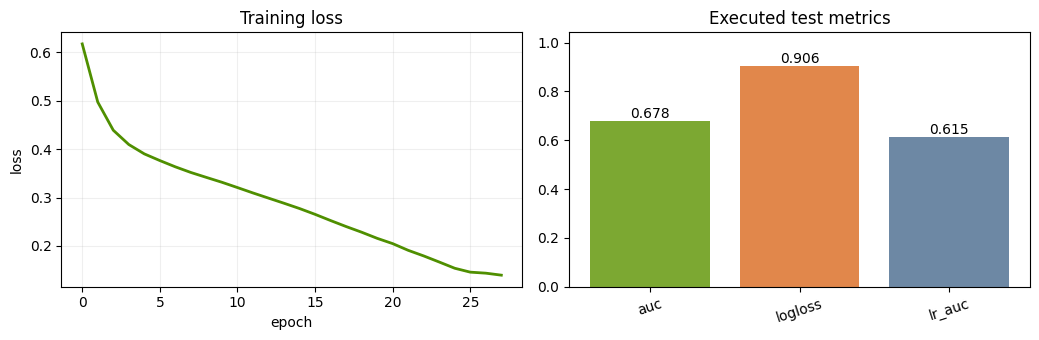

,value
auc,0.678114
logloss,0.906232
lr_auc,0.615080


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'auc': result['auc'], 'logloss': result['logloss'], 'lr_auc': result['lr_auc']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "Criteo Display Ads", "resource": "criteo-x1-full", "split": "7:2:1 fixed split from Criteo_x1", "metrics": ["AUC", "LogLoss"], "paper_targets": {"AUC": 0.8007, "LogLoss": 0.45083}}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

,metric,tutorial,paper,absolute_gap,comparable
0,AUC,0.678114,0.80070,None,False
1,LogLoss,0.906232,0.45083,None,False


NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 auc = **{result['auc']:.4f}**。
- 辅助指标 logloss = **{result['logloss']:.4f}**。
- 对照指标 lr_auc = **{result['lr_auc']:.4f}**。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** AUC 衡量排序而非概率准确度，必须同时看 LogLoss 与校准；KuaiRand 的随机干预比例和不同 tab 策略也会造成分布差异。

### 工业边界

读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 auc = **0.6781**。
- 辅助指标 logloss = **0.9062**。
- 对照指标 lr_auc = **0.6151**。
- 训练损失从 **0.6174** 降到 **0.1396**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** AUC 衡量排序而非概率准确度，必须同时看 LogLoss 与校准；KuaiRand 的随机干预比例和不同 tab 策略也会造成分布差异。

### 工业边界

读取请求和候选特征 → 查 embedding → FM 与 DNN 并行 → Sigmoid；线上校验词表、缺失值和 embedding 版本。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'DeepFM 排序',
    'primary_metric': 'auc', 'primary_value': float(result['auc']),
    'secondary_metric': 'logloss', 'secondary_value': float(result['logloss']),
    'baseline_metric': 'lr_auc',
    'baseline_value': float(result['lr_auc']) if True else None,
    'framework': result['framework'], 'source_notebook': '6_2_deepfm',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_6','6_2_deepfm',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_6/6_2_deepfm.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['auc']) <= 1
assert np.isfinite(float(result['logloss']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。